#Project 3: Linear Classification
Sophia and Devin

 Generate a dataset for yourself consisting of 2 classes from a multivariate normal distribution. Mu1 = [1 1], Mu2 = [-1 -1], Sigma = eye(1). Implement two different linear classifiers on this data, a Gaussian generative model, and a logistic regression classifier. For the logistic regression classifier, you must implement the IRLS algorithm.



Report your % correct classification (it should be very high for this simple dataset).



Plot a ROC curve for both of your classifiers, Plot the decision boundary for both your classifiers (hint, it should be a line)



Go to Kaggle or the UCI machine learning database, find a dataset that interests you, and try your classifiers on it. Make sure it is a binary dataset with only numerical features.

##Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create classifiers

##Gaussian Generative Model

In [ ]:
def gaussian_classifier(X, y):
  X1 = X[y == 1]  # class 1 samples
  X2 = X[y == 0]  # class 0 samples

  n_1 = X1.shape[0] # number of samples in class 1
  n_2 = X2.shape[0] # number of samples in class 2

  pi_1 = n_1 / (n_1 + n_2)  # class 1 prior
  pi_2 = n_2 / (n_1 + n_2)  # class 2 prior

  mu_1 = np.mean(X1, axis=0)  # estimated mean vector of class 1
  mu_2 = np.mean(X2, axis=0)  # estimated mean vector of class 2

  sigma_1 = np.cov(X1.T)  # estimated covariance of class 1
  sigma_2 = np.cov(X2.T)  # estimated covariance of class 2

  sigma = (n_1 * sigma_1 + n_2 * sigma_2) / (n_1 + n_2) # Shared covariance, weighted avg
  sigma_inv = np.linalg.inv(sigma)

  w = sigma_inv @ (mu_1 - mu_2) # weight vector
  w_0 = -0.5 * (mu_1.T @ sigma_inv @ mu_1) + 0.5 * (mu_2.T @ sigma_inv @ mu_2) + np.log(pi_1 / pi_2)  # bias

  return w, w_0

##Logistic Regression

In [ ]:
def logistic_regression(X, y, max_iter=100, tol=1e-6):
    n, d = X.shape
    X_int = np.hstack([np.ones((n, 1)), X]) # add intercept term

    # initialize parameters
    beta = np.zeros(d + 1)

    # IRLS iterations
    for iteration in range(max_iter):
        # compute predictions
        z = X_int @ beta
        p = 1 / (1 + np.exp(-z))

        # compute weights
        W = p * (1 - p)

        # compute gradient (first derivative)
        gradient = X_int.T @ (y - p)

        # compute Hessian (second derivative matrix)
        W_diag = np.diag(W)
        hessian = -X_int.T @ W_diag @ X_int

        # update parameters using Newton's method
        beta_new = beta - np.linalg.inv(hessian) @ gradient

        # check convergence
        if np.linalg.norm(beta_new - beta) < tol:
            break

        beta = beta_new

    # extract w and w_0
    w_0 = beta[0]
    w = beta[1:]

    return w, w_0

# Part 1: Generated Dataset

##Multivariate Normal Distribution

In [ ]:
n_samples = 200
mu1 = np.array([1, 1])
mu2 = np.array([-1, -1])
sigma = np.eye(2)

In [ ]:
X1 = np.random.multivariate_normal(mu1, sigma, int(n_samples/2))
X2 = np.random.multivariate_normal(mu2, sigma, int(n_samples/2))

X = np.vstack([X1, X2])
y = np.hstack([np.ones(int(n_samples/2)), np.zeros(int(n_samples/2))])

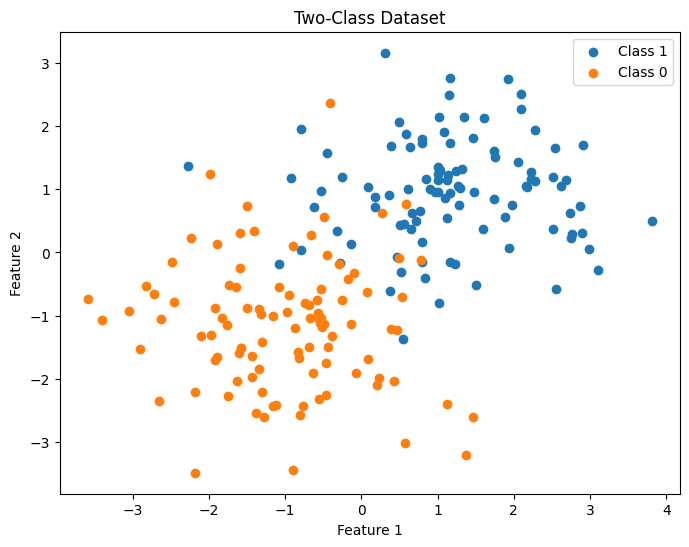

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], label='Class 0')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two-Class Dataset')
plt.legend()
plt.show()

##Results

In [ ]:
# Gaussian Generative Model
w_ggm, w_0_ggm = gaussian_classifier(X, y)

y_pred = ((X @ w_ggm + w_0_ggm) > 0).astype(int)  # if above decision boundary = class 1
accuracy_ggm = np.mean(y_pred == y)
print("Gaussian Generative Model Accuracy:", accuracy_ggm)

# Logistic Regression
w_lr, w_0_lr = logistic_regression(X, y)

z = X @ w_lr + w_0_lr # logit, raw score before sigmoid
p = 1 / (1 + np.exp(-z))  # apply sigmoid
y_pred_lr = (p > 0.5).astype(int) # if prob > 50%, class 1
accuracy_lr = np.mean(y_pred_lr == y)
print("Logistic Regression Accuracy:", accuracy_lr)

Gaussian Generative Model Accuracy: 0.94
Logistic Regression Accuracy: 0.94


##Plot

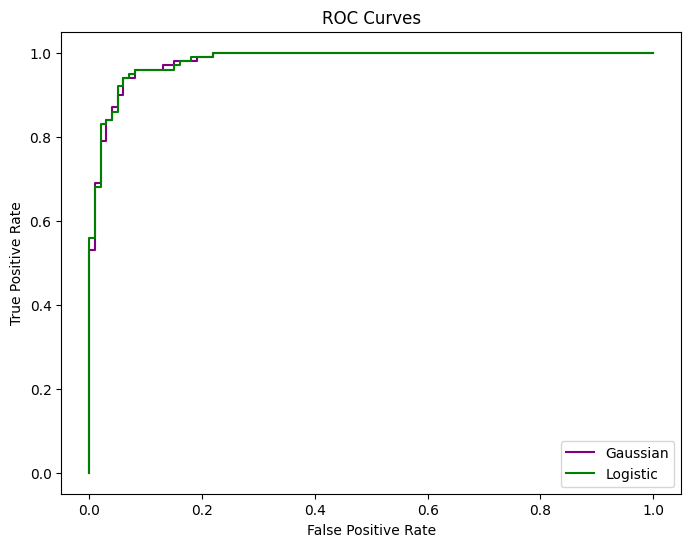

In [ ]:
scores_ggm = X @ w_ggm + w_0_ggm
scores_lr = X @ w_lr + w_0_lr

# The ROC curve is the plot of the true positive rate against the false positive rate
fpr_ggm, tpr_ggm, _ = roc_curve(y, scores_ggm)
fpr_lr, tpr_lr, _ = roc_curve(y, scores_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ggm, tpr_ggm, label='Gaussian', color = 'purple')
plt.plot(fpr_lr, tpr_lr, label='Logistic', color = 'green')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

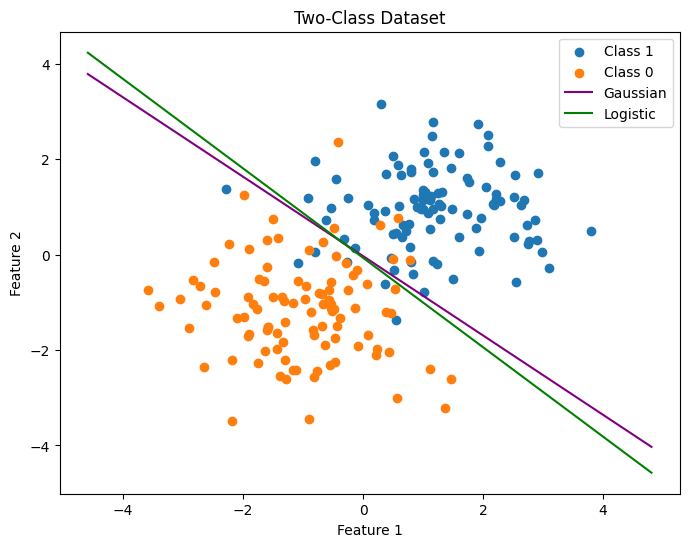

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], label='Class 0')

# Decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_boundary = np.array([x_min, x_max])

# Gaussian classifier
w_ggm, w_0_ggm = gaussian_classifier(X, y)
y_boundary_ggm = -(w_ggm[0] * x_boundary + w_0_ggm) / w_ggm[1]
plt.plot(x_boundary, y_boundary_ggm, label='Gaussian', color = 'purple')

# Logistic regression
w_lr, w_0_lr = logistic_regression(X, y)
y_boundary_lr = -(w_lr[0] * x_boundary + w_0_lr) / w_lr[1]
plt.plot(x_boundary, y_boundary_lr, label='Logistic', color = 'green')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two-Class Dataset')
plt.legend()
plt.show()

# Part 2: Online Dataset

Diabetes dataset predicting disease progression in patients. <br>
10 features <br>
2 classes: high disease progression (above median) and low disease progression (below median)

##Load and preprocess dataset

In [ ]:
# load diabetes dataset
data = load_diabetes()
X_diab = data.data
y_diab = (data.target > np.median(data.target)).astype(int)  # binarize above/below median for two classes

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_diab, y_diab, test_size=0.3, random_state=42)

print(f"Dataset shape: {X_diab.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Class distribution - High: {np.sum(y_diab == 1)}, Low: {np.sum(y_diab == 0)}")

Dataset shape: (442, 10)
Training set: 309 samples
Test set: 133 samples
Class distribution - High: 221, Low: 221


##Classify

In [ ]:
# Gaussian Generative Model
w_ggm, w_0_ggm = gaussian_classifier(X_train, y_train)
y_pred_ggm = ((X_test @ w_ggm + w_0_ggm) > 0).astype(int)  # if above decision boundary = class 1
accuracy_ggm = np.mean(y_pred_ggm == y_test)
print("Gaussian Generative Model Accuracy:", accuracy_ggm)

# Logistic Regression
w_lr, w_0_lr = logistic_regression(X_train, y_train)
z = X_test @ w_lr + w_0_lr # logit, raw score before sigmoid
p = 1 / (1 + np.exp(-z)) # apply sigmoid
y_pred_lr = (p > 0.5).astype(int) # if prob > 50%, class 1
accuracy_lr = np.mean(y_pred_lr == y_test)
print("Logistic Regression Accuracy:", accuracy_lr)

Gaussian Generative Model Accuracy: 0.7744360902255639
Logistic Regression Accuracy: 0.7744360902255639
